In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


importing data

In [4]:
train_df = pd.read_csv("Datast/train.csv")
test_df = pd.read_csv("Datast/test.csv")
building_df = pd.read_csv("Datast/building_metadata.csv")
weather_train_df = pd.read_csv("Datast/weather_train.csv")
weather_test_df = pd.read_csv("Datast/weather_test.csv")

In [5]:
print("train_df_shape ",train_df.shape)
print("building_df_shape",building_df.shape)
print("weather_train_df_shape",weather_train_df.shape)

train_df_shape  (20216100, 4)
building_df_shape (1449, 6)
weather_train_df_shape (139773, 9)


In [36]:
cp_main.iloc[1007:50000:1000]

,building_id,meter,meter_reading,site_id,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
1007,1136,0,39.5190,13,79782,NaN,NaN,-8.3,8.0,-12.2,NaN,1023.3,250.0,4.1
2007,674,0,48.7000,5,149704,1976.0,8.0,5.0,0.0,2.0,NaN,NaN,260.0,2.6
3007,1238,2,379.2250,14,129707,NaN,NaN,5.6,0.0,-0.6,0.0,1019.3,300.0,2.6
4007,367,0,48.8600,3,20584,NaN,NaN,8.9,NaN,2.2,0.0,1021.7,10.0,4.6
5007,1097,2,1578.1200,13,157545,NaN,NaN,-7.8,NaN,-11.1,-1.0,1022.9,240.0,3.1
6007,186,0,3.4900,2,1629,1948.0,NaN,12.2,0.0,-6.1,0.0,1016.6,280.0,3.1
7007,942,0,37.0000,9,57334,NaN,NaN,10.0,NaN,3.9,0.0,1028.9,30.0,3.6
8007,1405,0,132.8750,15,142901,2007.0,NaN,-1.0,NaN,-2.0,NaN,NaN,340.0,2.1
9007,771,1,0.0000,6,82911,NaN,NaN,7.8,2.0,3.9,0.0,1020.6,50.0,2.1
10007,1277,0,62.4816,14,45240,NaN,NaN,5.0,NaN,-2.2,0.0,1019.2,290.0,3.1


In [6]:
train_merged = train_df.merge(building_df, on="building_id", how="inner")
main_merged = train_merged.merge(weather_train_df, on=["site_id", "timestamp"], how="inner")
main_merged.columns

Index(['building_id', 'meter', 'timestamp', 'meter_reading', 'site_id',
       'primary_use', 'square_feet', 'year_built', 'floor_count',
       'air_temperature', 'cloud_coverage', 'dew_temperature',
       'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction',
       'wind_speed'],
      dtype='object')

In [7]:
# main_merged.head()
# train_merged.head()
# train_merged.isnull().sum()
main_merged.shape

(20125605, 16)

copy of main dataframe

In [103]:
cp_main=main_merged.copy()

In [104]:
cp_main = cp_main.dropna(subset=['floor_count'])

In [112]:
cp_main.isnull().sum()

building_id           0
meter                 0
timestamp             0
meter_reading         0
site_id               0
primary_use           0
square_feet           0
year_built            0
floor_count           0
air_temperature       0
cloud_coverage        0
dew_temperature       0
sea_level_pressure    0
wind_direction        0
wind_speed            0
dtype: int64

In [105]:
cp_main["cloud_coverage"] = cp_main["cloud_coverage"].fillna(method="ffill")
cp_main["dew_temperature"] = cp_main["dew_temperature"].fillna(cp_main['dew_temperature'].mean())



C:\Users\zyzai\AppData\Local\Temp\ipykernel_11552\3025183886.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cp_main["cloud_coverage"] = cp_main["cloud_coverage"].fillna(method="ffill")


In [106]:
cp_main["wind_speed"] = cp_main["wind_speed"].fillna(cp_main['wind_speed'].mean())
cp_main["wind_direction"] = cp_main["wind_direction"].fillna(cp_main['wind_direction'].median())



In [107]:
cp_main.drop(columns=['precip_depth_1_hr'],inplace=True)

In [108]:
cp_main = cp_main.dropna(subset=['cloud_coverage','air_temperature'])

In [109]:
cp_main["year_built"] = cp_main["year_built"].fillna(1959)


In [71]:
cp_main.head()

,building_id,meter,meter_reading,site_id,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
103,105,0,23.3036,1,50623,NaN,5.0,3.8,NaN,2.4,NaN,1020.9,240.0,3.1
104,106,0,0.3746,1,5374,NaN,4.0,3.8,NaN,2.4,NaN,1020.9,240.0,3.1
105,106,3,0.0000,1,5374,NaN,4.0,3.8,NaN,2.4,NaN,1020.9,240.0,3.1
106,107,0,175.1840,1,97532,2005.0,10.0,3.8,NaN,2.4,NaN,1020.9,240.0,3.1
107,108,0,91.2653,1,81580,1913.0,5.0,3.8,NaN,2.4,NaN,1020.9,240.0,3.1


In [113]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split



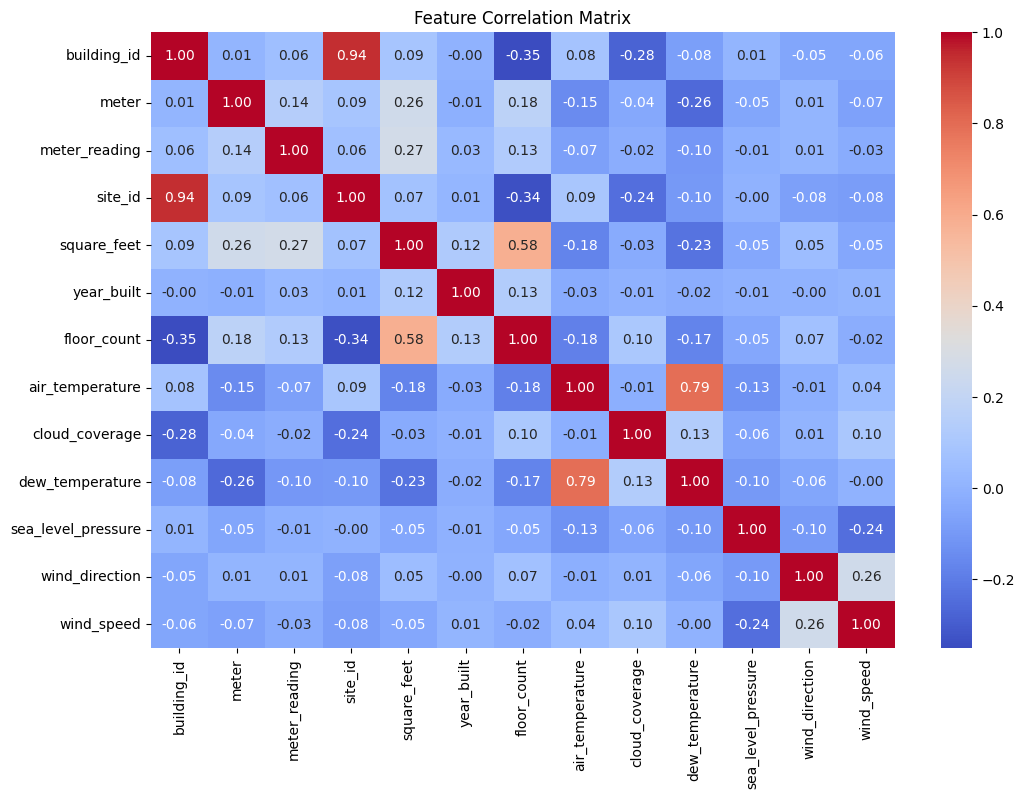

In [86]:
corrmat=cp_main.corr()
# model.fit(X, y)
plt.figure(figsize=(12,8))
sns.heatmap(corrmat, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

In [88]:
# cp_main.describe()
cp_main.iloc[1000:10000:100]

,building_id,meter,meter_reading,site_id,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,sea_level_pressure,wind_direction,wind_speed
6558,631,0,10.0025,4,23533,1906.0,3.0,7.8,0.0,-2.8,1021.700000,90.0,1.5
6658,732,0,30.4000,5,66187,1976.0,1.0,4.0,0.0,3.0,1016.475727,160.0,2.6
6824,851,0,117.7080,8,16682,1959.0,1.0,21.1,2.0,20.6,1020.100000,0.0,0.0
8197,118,0,239.8000,1,138316,1960.0,8.0,2.3,0.0,1.8,1022.700000,110.0,1.5
8851,629,0,9.3000,4,40835,1931.0,6.0,5.0,0.0,-0.6,1021.800000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
52715,694,0,4.6000,5,30613,1976.0,4.0,9.0,4.0,8.0,1016.475727,110.0,10.3
52881,811,0,8.3333,8,4848,1959.0,1.0,24.4,6.0,18.9,1018.100000,270.0,2.6
53285,1020,0,89.3702,10,22101,1959.0,2.0,-8.9,0.0,-15.6,1033.000000,300.0,3.1
54910,584,0,100.0800,4,137806,1967.0,8.0,7.8,4.0,-4.4,1020.100000,30.0,4.1


In [ ]:
cp_main.duplicated().sum()

In [ ]:
cp_main.isna().sum()

In [ ]:
missing_percentage = main_merged.isnull().sum() / len(main_merged) * 100
print(missing_percentage.sort_values(ascending=False))
main_merged.hist(bins=50,figsize=(20,18))

In [ ]:
# print(cp_main[['year_built', 'meter_reading']].corr())
# print(cp_main[['floor_count', 'meter_reading']].corr())

COnversion of site 0 to kWh

In [ ]:
cp_main.loc[(cp_main["site_id"] == 0) & (cp_main["meter"] == 0), "meter_reading"] *= 0.293071

In [ ]:
cp_main.drop(columns=['year_built'],inplace=True)
cp_main.drop(columns=['floor_count'],inplace=True)
# cp_main.drop(columns=['floor_count','year_built','wind_speed','dew_temperature','air_temperature'],inplace=True)
cp_main.columns

In [ ]:
cp_main['wind_speed'].isna().sum()

In [ ]:
cp_main.dropna(subset=['wind_speed','dew_temperature','air_temperature'],inplace=True)
cp_main['wind_speed'].isna().sum()

In [98]:
cp_main['sea_level_pressure'] = cp_main['sea_level_pressure'].fillna(cp_main['sea_level_pressure'].rolling(window=5, min_periods=1).mean())

In [ ]:
cp_main["cloud_coverage"] = cp_main["cloud_coverage"].fillna(method="ffill")
# cp_main["precip_depth_1_hr"] = cp_main["precip_depth_1_hr"].interpolate()
cp_main.loc[cp_main['sea_level_pressure'].isnull(), 'sea_level_pressure'] = np.random.choice(cp_main['sea_level_pressure'].dropna(), size=cp_main['sea_level_pressure'].isnull().sum(), replace=True)

In [110]:
import numpy as np

# Define the range for uniform distribution
min_val = cp_main['sea_level_pressure'].min()
max_val = cp_main['sea_level_pressure'].max()

# Generate random values within this range for NaNs
cp_main['sea_level_pressure'] = cp_main['sea_level_pressure'].apply(
    lambda x: np.random.uniform(min_val, max_val) if np.isnan(x) else x
)

building_id           0.0
meter                 0.0
timestamp             0.0
meter_reading         0.0
site_id               0.0
primary_use           0.0
square_feet           0.0
year_built            0.0
floor_count           0.0
air_temperature       0.0
cloud_coverage        0.0
dew_temperature       0.0
sea_level_pressure    0.0
wind_direction        0.0
wind_speed            0.0
dtype: float64


array([[<Axes: title={'center': 'building_id'}>,
        <Axes: title={'center': 'meter'}>,
        <Axes: title={'center': 'meter_reading'}>,
        <Axes: title={'center': 'site_id'}>],
       [<Axes: title={'center': 'square_feet'}>,
        <Axes: title={'center': 'year_built'}>,
        <Axes: title={'center': 'floor_count'}>,
        <Axes: title={'center': 'air_temperature'}>],
       [<Axes: title={'center': 'cloud_coverage'}>,
        <Axes: title={'center': 'dew_temperature'}>,
        <Axes: title={'center': 'sea_level_pressure'}>,
        <Axes: title={'center': 'wind_direction'}>],
       [<Axes: title={'center': 'wind_speed'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

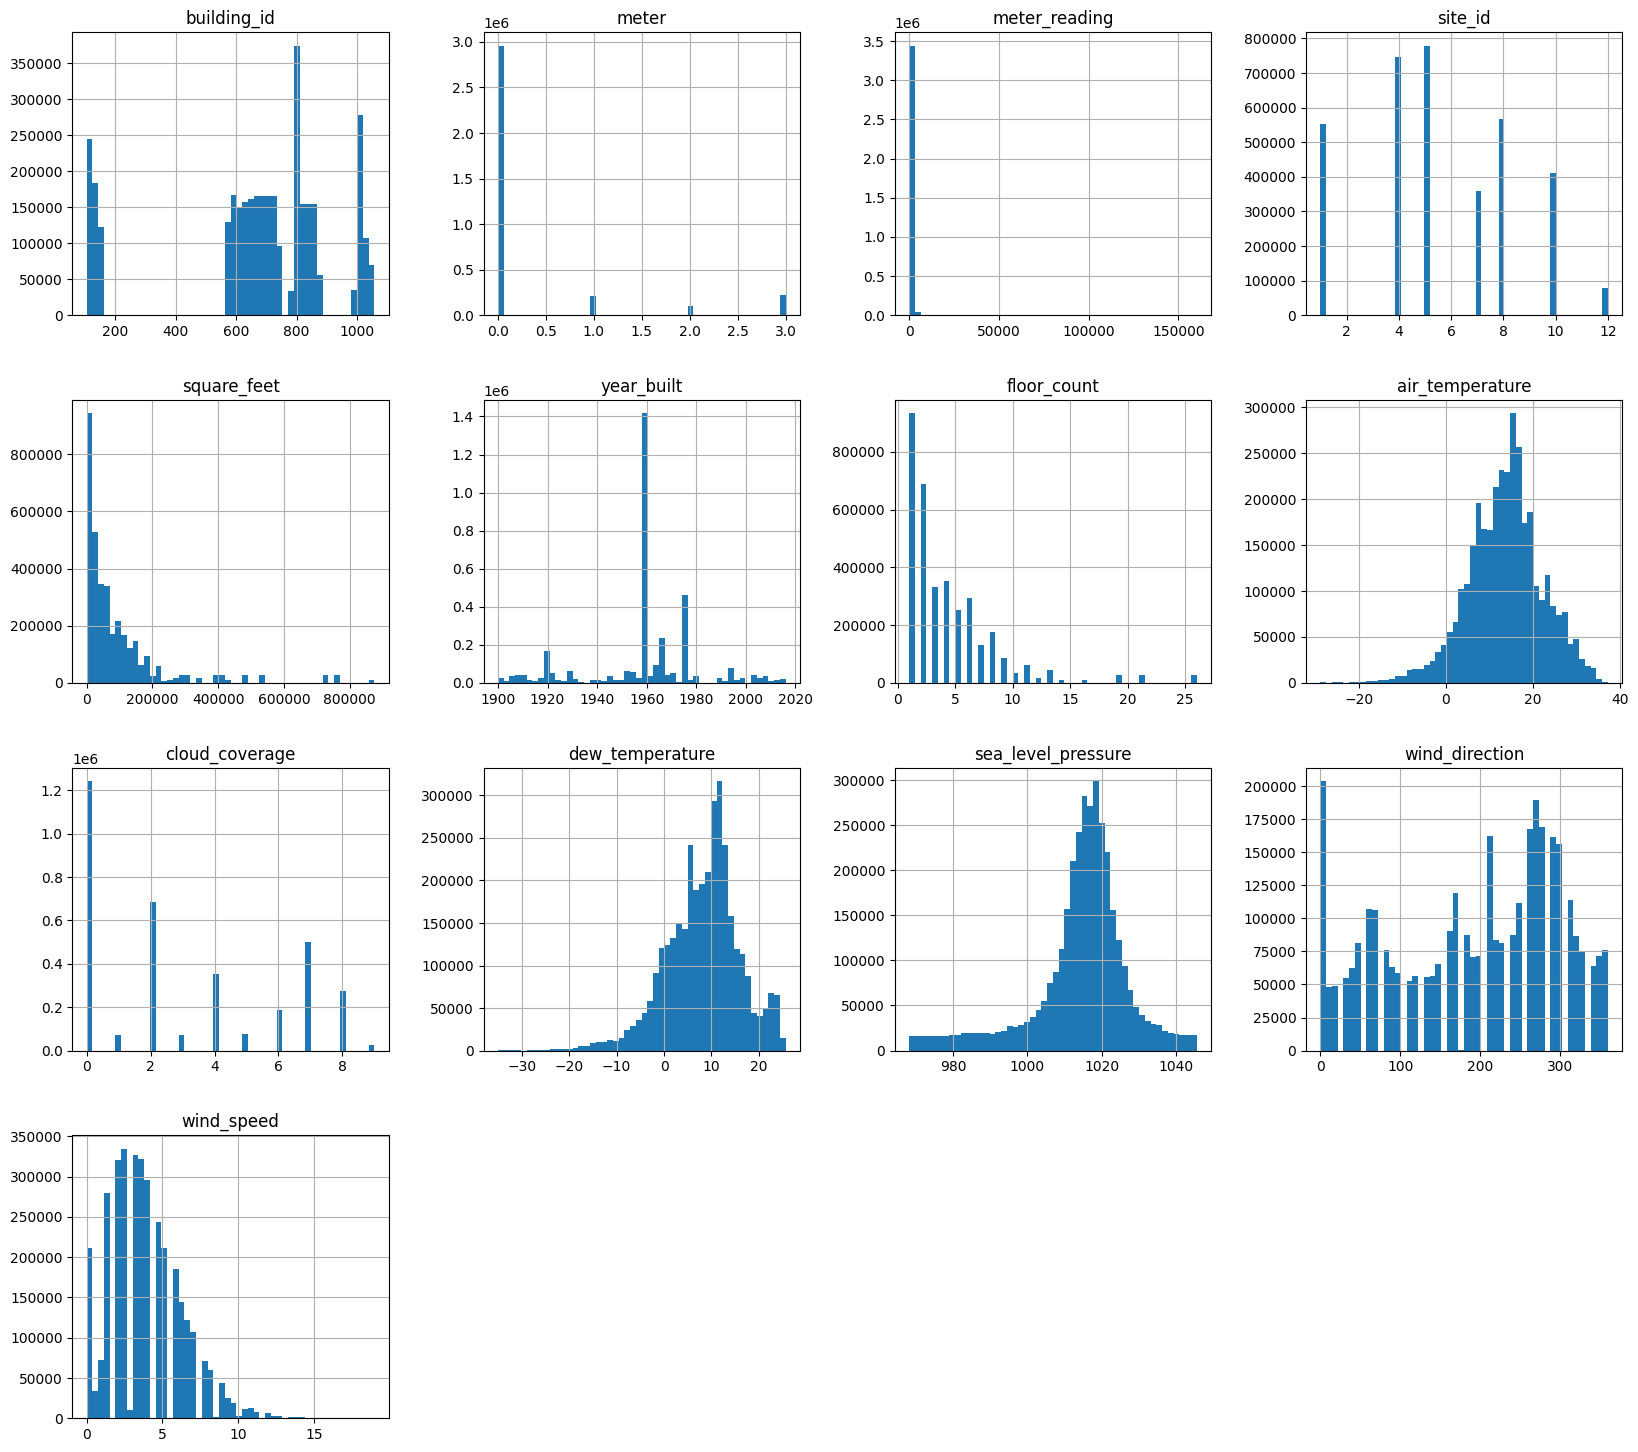

In [111]:
missing_percentage = cp_main.isnull().sum() / len(cp_main) * 100
print(missing_percentage.sort_values(ascending=False))
cp_main.hist(bins=50,figsize=(20,18))

FIRST CHECKPOINT

In [114]:
cp_main.head()

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,sea_level_pressure,wind_direction,wind_speed
764,804,0,2016-01-01 00:00:00,368.5830,8,Office,175618,1959.0,1.0,25.0,6.0,20.0,1019.7,0.0,0.0
765,805,0,2016-01-01 00:00:00,5.2500,8,Entertainment/public assembly,3200,1959.0,1.0,25.0,6.0,20.0,1019.7,0.0,0.0
766,806,0,2016-01-01 00:00:00,8.0833,8,Other,28693,1959.0,2.0,25.0,6.0,20.0,1019.7,0.0,0.0
767,807,0,2016-01-01 00:00:00,2.7917,8,Entertainment/public assembly,3000,1959.0,1.0,25.0,6.0,20.0,1019.7,0.0,0.0
768,808,0,2016-01-01 00:00:00,0.1250,8,Other,9357,1959.0,1.0,25.0,6.0,20.0,1019.7,0.0,0.0


In [ ]:
xyz=cp_main.copy()

In [ ]:
# xyz['wind_direction'].fillna(xyz['wind_direction'].mean(), inplace=True)
col=['air_temperature', 'cloud_coverage','dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure','wind_direction', 'wind_speed']
for i in col:
    plt.figure(figsize=(5, 4))  # Create a new figure for each boxplot
    xyz.boxplot(column=i)
    plt.title(f"Boxplot of {i}")
    plt.show()
# # sns.boxplot(xyz['wind_direction'])
# col

In [ ]:
def replace_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Replace outliers with median
        median = df[col].median()
        df[col] = df[col].apply(lambda x: median if x < lower_bound or x > upper_bound else x)
    
    return df

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix 
X = cp_main.drop(columns=['meter_reading'])  # Features
y = cp_main['meter_reading']  # Target


feature_importance = abs(model.coef_[0])
feature_names = X.columns

important_features = pd.Series(feature_importance, index=feature_names).sort_values(ascending=False)
important_features.plot(kind='bar', figsize=(10,5), title="Feature Importance in Logistic Regression")
plt.show()

In [ ]:
replace_outliers(xyz,col)
    # print(i)

In [ ]:
drop_0readings= list(cp_main[cp_main['meter_reading']==0.0].index)
cp_main.drop(drop_0readings, axis=0, inplace=True)

In [ ]:
# xyz['wind_direction'].fillna(xyz['wind_direction'].mean(), inplace=True)
col=['air_temperature', 'cloud_coverage','dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure','wind_direction', 'wind_speed']
for i in col:
    plt.figure(figsize=(5, 4))  # Create a new figure for each boxplot
    xyz.boxplot(column=i)
    plt.title(f"Boxplot of {i}")
    plt.show()  
# # sns.boxplot(xyz['wind_direction'])
# col

In [ ]:
xyz.hist(bins=50,figsize=(20,18))